<a href="https://colab.research.google.com/github/krishnamohan15/Fake-Job-Posting-Detection/blob/main/Fake_Job_Posting_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("DataSet.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset loaded successfully!
Shape: (17880, 18)

Columns:
['title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent', 'in_balanced_dataset']

First 5 rows:


,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent,in_balanced_dataset
0,Marketing Intern,"US, NY, New York",Marketing,NaN,"<h3>We're Food52, and we've created a groundbr...","<p>Food52, a fast-growing, James Beard Award-w...",<ul>\r\n<li>Experience with content management...,NaN,f,t,f,Other,Internship,NaN,NaN,Marketing,f,f
1,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"<h3>90 Seconds, the worlds Cloud Video Product...",<p>Organised - Focused - Vibrant - Awesome!<br...,<p><b>What we expect from you:</b></p>\r\n<p>Y...,<h3><b>What you will get from us</b></h3>\r\n<...,f,t,f,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,f,f
2,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,<h3></h3>\r\n<p>Valor Services provides Workfo...,"<p>Our client, located in Houston, is actively...",<ul>\r\n<li>Implement pre-commissioning and co...,NaN,f,t,f,NaN,NaN,NaN,NaN,NaN,f,f
3,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,<p>Our passion for improving quality of life t...,<p><b>THE COMPANY: ESRI – Environmental System...,<ul>\r\n<li>\r\n<b>EDUCATION: </b>Bachelor’s o...,<p>Our culture is anything but corporate—we ha...,f,t,f,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,f,f
4,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,<p>SpotSource Solutions LLC is a Global Human ...,<p><b>JOB TITLE:</b> Itemization Review Manage...,<p><b>QUALIFICATIONS:</b></p>\r\n<ul>\r\n<li>R...,<p>Full Benefits Offered</p>,f,t,t,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,f,f


Basic dataset information

In [2]:
print("Dataset Information:")
df.info()

print("\nMissing Values:")
display(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nTarget Distribution:")
display(df["fraudulent"].value_counts())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   title                17880 non-null  object
 1   location             17534 non-null  object
 2   department           6333 non-null   object
 3   salary_range         2868 non-null   object
 4   company_profile      14572 non-null  object
 5   description          17880 non-null  object
 6   requirements         15191 non-null  object
 7   benefits             10684 non-null  object
 8   telecommuting        17880 non-null  object
 9   has_company_logo     17880 non-null  object
 10  has_questions        17880 non-null  object
 11  employment_type      14409 non-null  object
 12  required_experience  10830 non-null  object
 13  required_education   9775 non-null   object
 14  industry             12977 non-null  object
 15  function             11425 non-n

,0
title,0
location,346
department,11547
salary_range,15012
company_profile,3308
description,0
requirements,2689
benefits,7196
telecommuting,0
has_company_logo,0



Duplicate Rows: 235

Target Distribution:


,count
fraudulent,
f,17014
t,866


DATA UNDERSTANDING + EDA

In [3]:
# Display all columns with their data types

print("Column Information")
print("=" * 60)

for column in df.columns:
    print(f"{column:25} -> {df[column].dtype}")

Column Information
title                     -> object
location                  -> object
department                -> object
salary_range              -> object
company_profile           -> object
description               -> object
requirements              -> object
benefits                  -> object
telecommuting             -> object
has_company_logo          -> object
has_questions             -> object
employment_type           -> object
required_experience       -> object
required_education        -> object
industry                  -> object
function                  -> object
fraudulent                -> object
in_balanced_dataset       -> object


In [4]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include="object").columns.tolist()

print("Numerical Columns:")
print(numeric_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
[]

Categorical Columns:
['title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent', 'in_balanced_dataset']


In [5]:
display(df.describe(include="all").T)

,count,unique,top,freq
title,17880,11231,English Teacher Abroad,311
location,17534,3105,"GB, LND, London",718
department,6333,1337,Sales,551
salary_range,2868,874,0-0,142
company_profile,14572,1710,<p>We help teachers get safe &amp; secure jobs...,726
description,17880,15095,"<p>Play with kids, get paid for it </p>\r\n<p>...",376
requirements,15191,12119,<p>University degree required. TEFL / TESOL / ...,410
benefits,10684,6510,<p>See job description</p>,726
telecommuting,17880,2,f,17113
has_company_logo,17880,2,t,14220


Check missing values properly

In [6]:
missing = df.isnull().sum().sort_values(ascending=False)

missing_percentage = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

missing_table = pd.DataFrame({
    "Missing Count": missing,
    "Missing Percentage": missing_percentage
})

display(missing_table)

,Missing Count,Missing Percentage
salary_range,15012,83.959732
department,11547,64.580537
required_education,8105,45.329978
benefits,7196,40.246085
required_experience,7050,39.429530
function,6455,36.101790
industry,4903,27.421700
employment_type,3471,19.412752
company_profile,3308,18.501119
requirements,2689,15.039150


Remove duplicates

In [7]:
print("Before removing duplicates:", df.shape)

df = df.drop_duplicates().reset_index(drop=True)

print("After removing duplicates:", df.shape)

Before removing duplicates: (17880, 18)
After removing duplicates: (17645, 18)


In [8]:
print("Target Distribution")

target_counts = df["fraudulent"].value_counts()

display(target_counts)

print("\nTarget Percentages:")

display(
    (df["fraudulent"].value_counts(normalize=True) * 100).round(2)
)

Target Distribution


,count
fraudulent,
f,16787
t,858



Target Percentages:


,proportion
fraudulent,
f,95.14
t,4.86


Target distribution graph

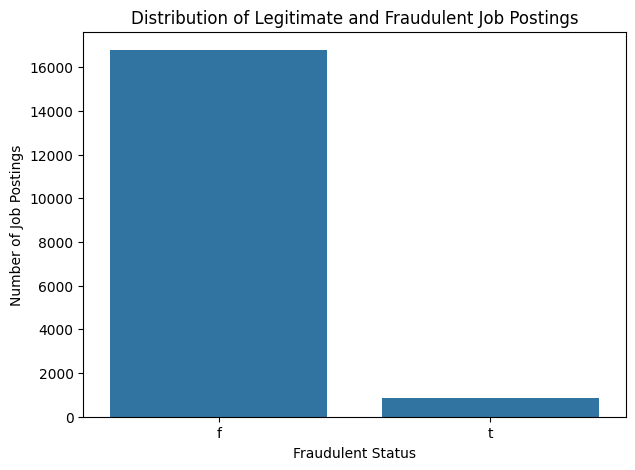

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="fraudulent"
)

plt.title("Distribution of Legitimate and Fraudulent Job Postings")
plt.xlabel("Fraudulent Status")
plt.ylabel("Number of Job Postings")

plt.show()

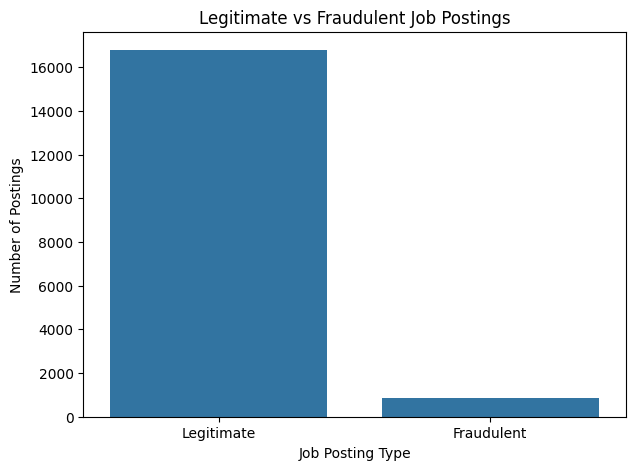

In [10]:
target_labels = df["fraudulent"].map({
    "f": "Legitimate",
    "t": "Fraudulent"
})

plt.figure(figsize=(7,5))

sns.countplot(x=target_labels)

plt.title("Legitimate vs Fraudulent Job Postings")
plt.xlabel("Job Posting Type")
plt.ylabel("Number of Postings")

plt.show()

Numerical distributions

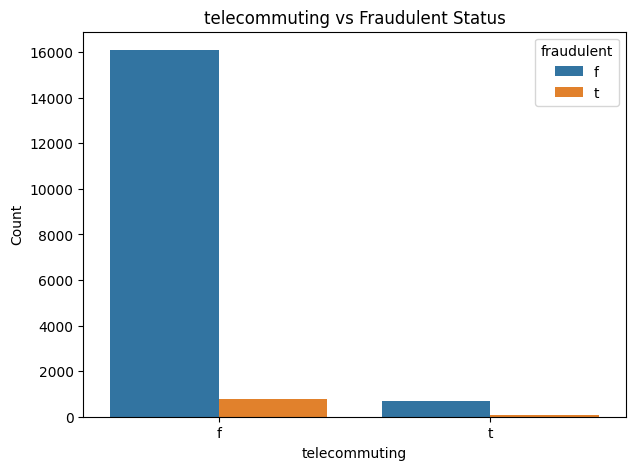

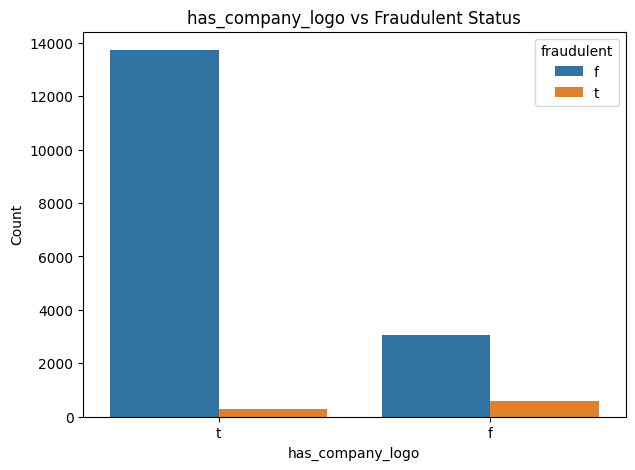

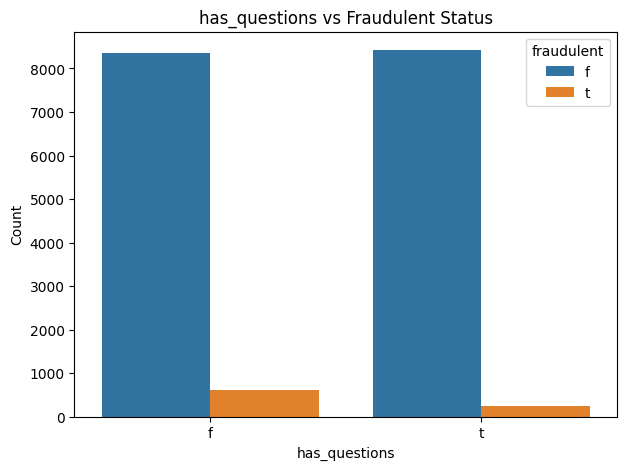

In [11]:
numeric_features = [
    "telecommuting",
    "has_company_logo",
    "has_questions"
]

for column in numeric_features:

    plt.figure(figsize=(7,5))

    sns.countplot(
        data=df,
        x=column,
        hue="fraudulent"
    )

    plt.title(f"{column} vs Fraudulent Status")
    plt.xlabel(column)
    plt.ylabel("Count")

    plt.show()

Fraud rate for each binary feature

In [12]:
for column in numeric_features:

    print("\n", "="*60)
    print(column)

    fraud_rate = (
        df.groupby(column)["fraudulent"]
        .apply(lambda x: (x == "t").mean() * 100)
    )

    display(fraud_rate)


telecommuting


,fraudulent
telecommuting,
f,4.701285
t,8.465608



has_company_logo


,fraudulent
has_company_logo,
f,15.850303
t,2.012704



has_questions


,fraudulent
has_questions,
f,6.790055
t,2.869986


CATEGORICAL ANALYSIS

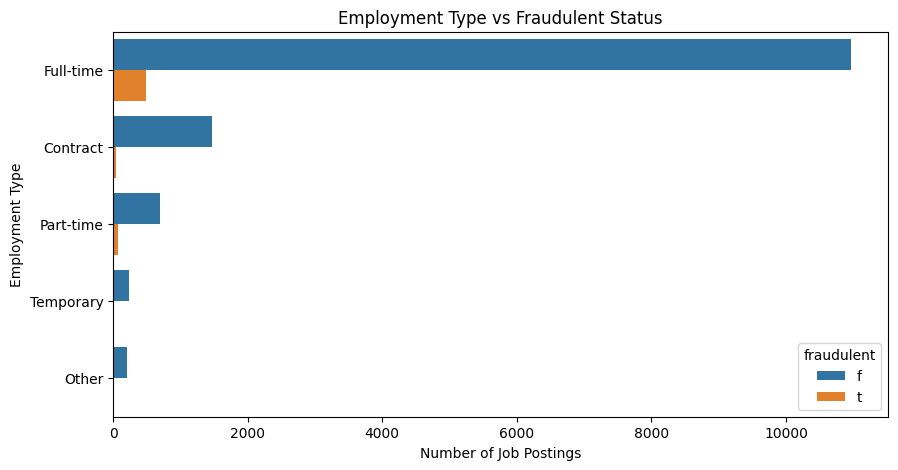

In [13]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    y="employment_type",
    hue="fraudulent",
    order=df["employment_type"].value_counts().index
)

plt.title("Employment Type vs Fraudulent Status")
plt.xlabel("Number of Job Postings")
plt.ylabel("Employment Type")

plt.show()

Required experience

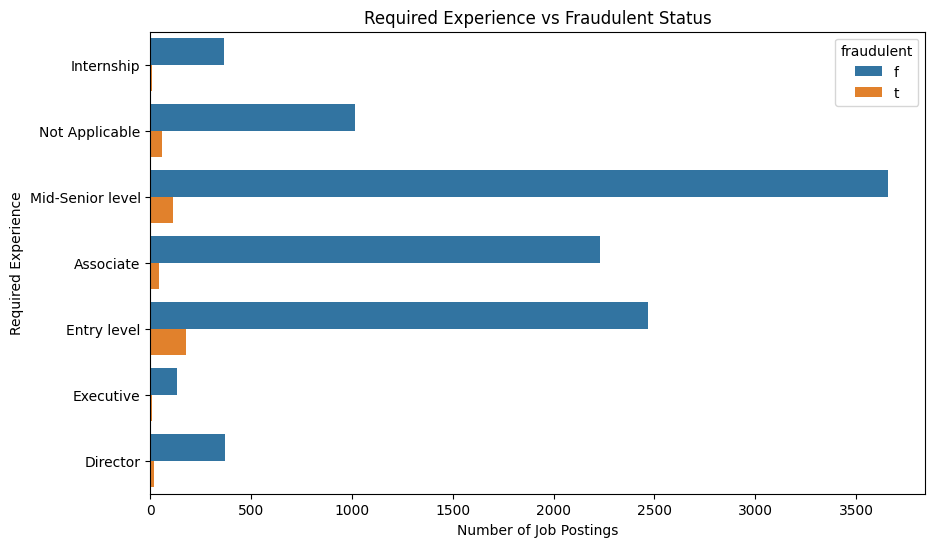

In [14]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    y="required_experience",
    hue="fraudulent"
)

plt.title("Required Experience vs Fraudulent Status")
plt.xlabel("Number of Job Postings")
plt.ylabel("Required Experience")

plt.show()

Required education

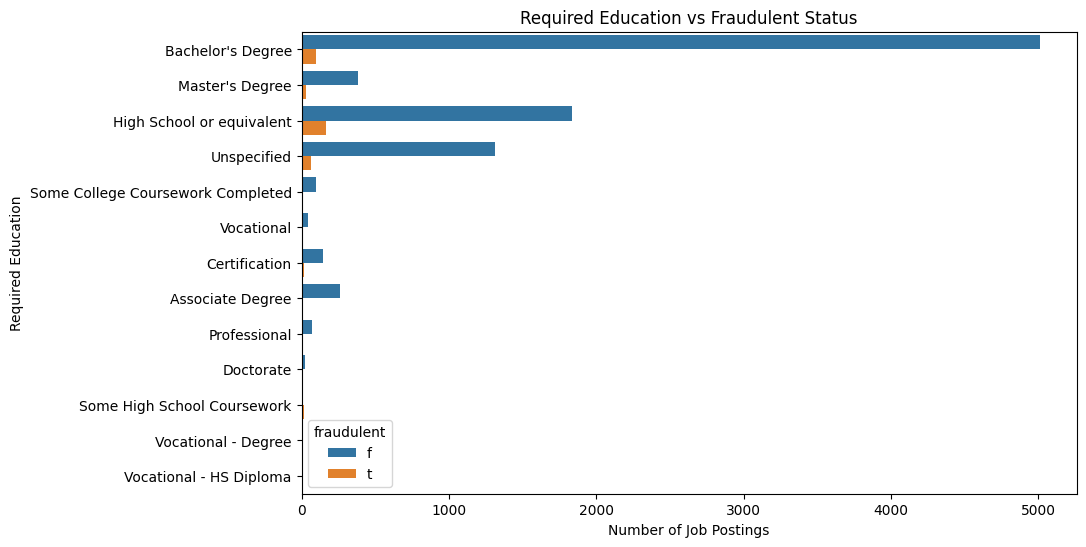

In [15]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    y="required_education",
    hue="fraudulent"
)

plt.title("Required Education vs Fraudulent Status")
plt.xlabel("Number of Job Postings")
plt.ylabel("Required Education")

plt.show()

Industry analysis

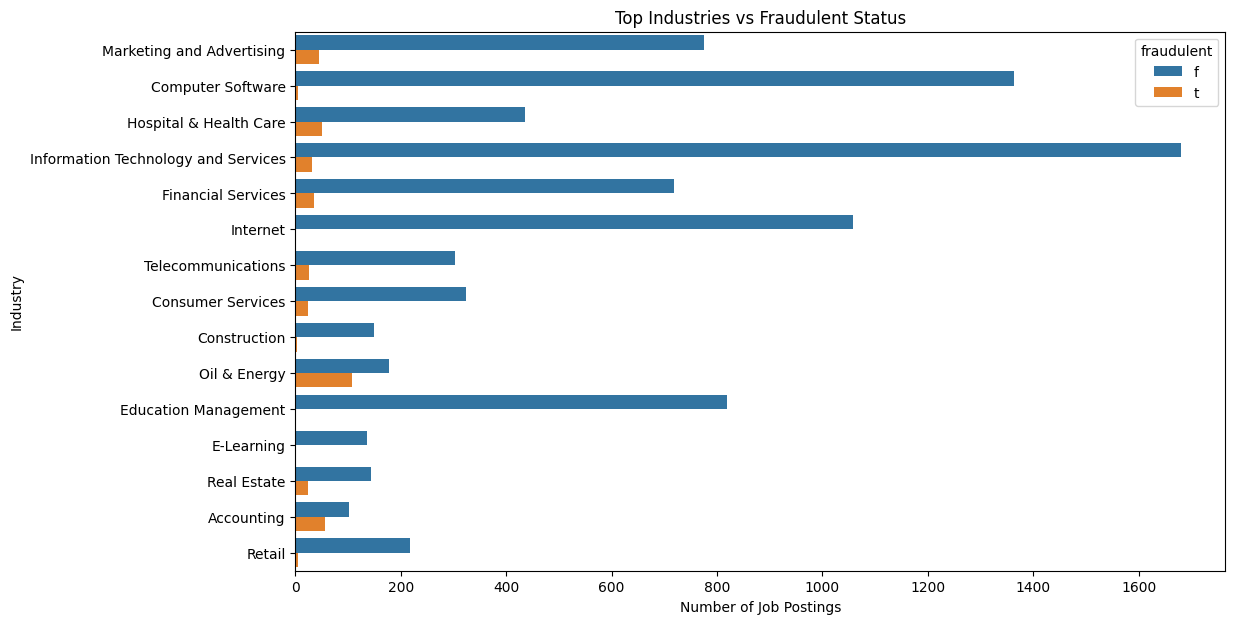

In [16]:
top_industries = df["industry"].value_counts().head(15).index

plt.figure(figsize=(12,7))

sns.countplot(
    data=df[df["industry"].isin(top_industries)],
    y="industry",
    hue="fraudulent"
)

plt.title("Top Industries vs Fraudulent Status")
plt.xlabel("Number of Job Postings")
plt.ylabel("Industry")

plt.show()

Function analysis

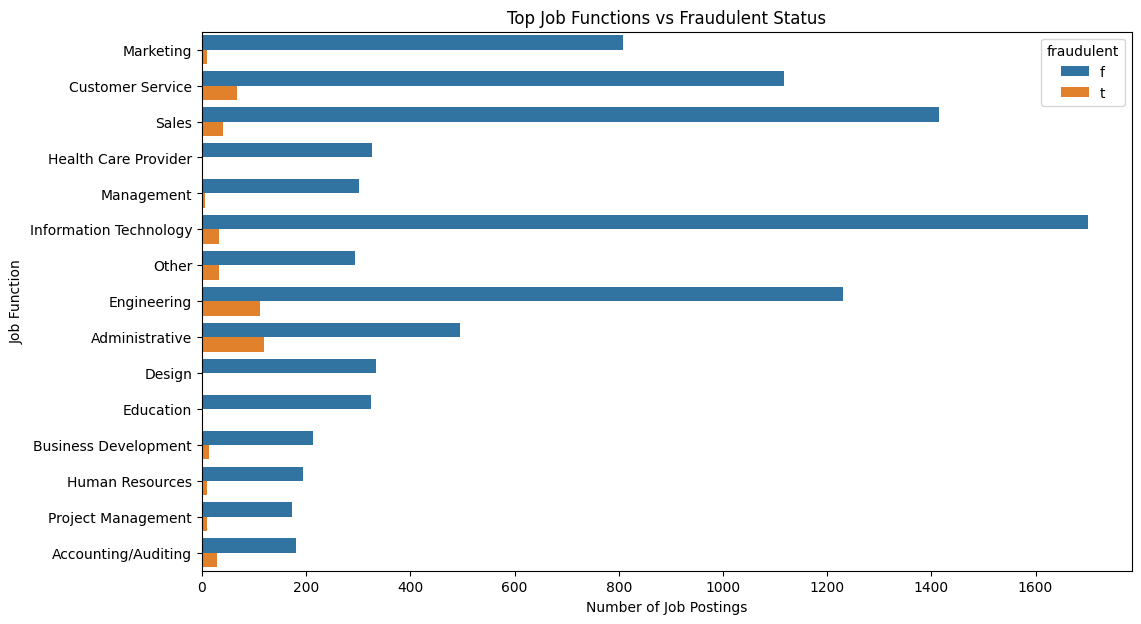

In [17]:
top_functions = df["function"].value_counts().head(15).index

plt.figure(figsize=(12,7))

sns.countplot(
    data=df[df["function"].isin(top_functions)],
    y="function",
    hue="fraudulent"
)

plt.title("Top Job Functions vs Fraudulent Status")
plt.xlabel("Number of Job Postings")
plt.ylabel("Job Function")

plt.show()

Analyze text lengths

In [18]:
text_columns = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

for column in text_columns:

    df[column] = df[column].fillna("")

    df[column + "_length"] = df[column].str.len()

display(
    df[
        [column + "_length" for column in text_columns]
    ].describe().T
)

,count,mean,std,min,25%,50%,75%,max
title_length,17645.0,28.412695,13.778753,3.0,19.0,25.0,34.0,142.0
company_profile_length,17645.0,692.757098,649.703490,0.0,150.0,613.0,966.0,6450.0
description_length,17645.0,1439.338339,1723.069230,10.0,674.0,1157.0,1776.0,55130.0
requirements_length,17645.0,732.921054,1260.299472,0.0,183.0,565.0,971.0,37994.0
benefits_length,17645.0,267.880419,668.944080,0.0,0.0,62.0,360.0,19455.0


Compare description length

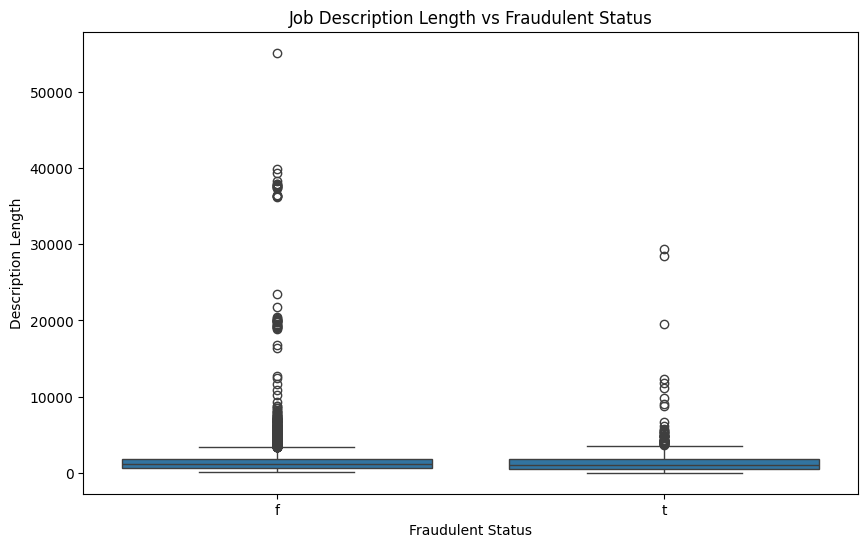

In [19]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="fraudulent",
    y="description_length"
)

plt.title("Job Description Length vs Fraudulent Status")
plt.xlabel("Fraudulent Status")
plt.ylabel("Description Length")

plt.show()

requirements length

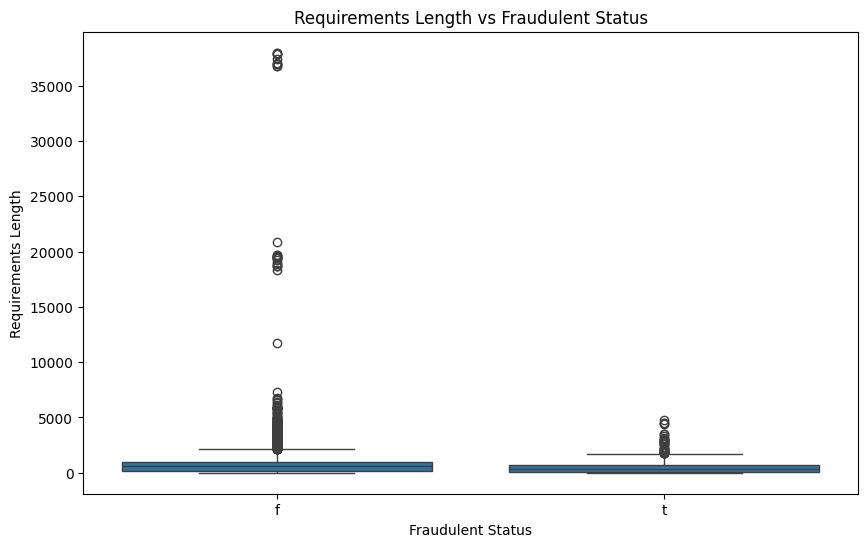

In [20]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="fraudulent",
    y="requirements_length"
)

plt.title("Requirements Length vs Fraudulent Status")
plt.xlabel("Fraudulent Status")
plt.ylabel("Requirements Length")

plt.show()

Word frequency analysis

In [21]:
df["combined_text"] = (
    df["title"] + " " +
    df["company_profile"] + " " +
    df["description"] + " " +
    df["requirements"] + " " +
    df["benefits"]
)

print(df["combined_text"].head())

0    Marketing Intern <h3>We're Food52, and we've c...
1    Customer Service - Cloud Video Production <h3>...
2    Commissioning Machinery Assistant (CMA) <h3></...
3    Account Executive - Washington DC <p>Our passi...
4    Bill Review Manager <p>SpotSource Solutions LL...
Name: combined_text, dtype: object


Text cleaning function

In [23]:
import re

def clean_text(text):

    text = str(text).lower()

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Keep only letters and spaces
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

text cleaning

In [24]:
df["clean_text"] = df["combined_text"].apply(clean_text)

display(
    df[["combined_text", "clean_text"]].head()
)

,combined_text,clean_text
0,"Marketing Intern <h3>We're Food52, and we've c...",marketing intern we re food and we ve created ...
1,Customer Service - Cloud Video Production <h3>...,customer service cloud video production second...
2,Commissioning Machinery Assistant (CMA) <h3></...,commissioning machinery assistant cma valor se...
3,Account Executive - Washington DC <p>Our passi...,account executive washington dc our passion fo...
4,Bill Review Manager <p>SpotSource Solutions LL...,bill review manager spotsource solutions llc i...


Convert target

In [25]:
df["target"] = df["fraudulent"].map({
    "f": 0,
    "t": 1
})

print(df["target"].value_counts())

target
0    16787
1      858
Name: count, dtype: int64


invalid target values

In [26]:
print("Missing target values:", df["target"].isnull().sum())

Missing target values: 0


Train/test split

In [27]:
from sklearn.model_selection import train_test_split

X = df["clean_text"]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 14116
Testing samples: 3529


Create TF-IDF

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=50000,
    stop_words="english",
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (14116, 50000)
Testing TF-IDF shape: (3529, 50000)


FIRST MODEL Logistic Regression

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

lr_pred = lr_model.predict(X_test_tfidf)

print("Logistic Regression Results")
print("=" * 50)

print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall   :", recall_score(y_test, lr_pred))
print("F1 Score :", f1_score(y_test, lr_pred))

print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

Logistic Regression Results
Accuracy : 0.9756304902238595
Precision: 0.7128712871287128
Recall   : 0.8372093023255814
F1 Score : 0.7700534759358288

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      3357
           1       0.71      0.84      0.77       172

    accuracy                           0.98      3529
   macro avg       0.85      0.91      0.88      3529
weighted avg       0.98      0.98      0.98      3529



NAIVE BAYES

In [30]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

nb_pred = nb_model.predict(X_test_tfidf)

print("Naive Bayes Results")
print("=" * 50)

print("Accuracy :", accuracy_score(y_test, nb_pred))
print("Precision:", precision_score(y_test, nb_pred))
print("Recall   :", recall_score(y_test, nb_pred))
print("F1 Score :", f1_score(y_test, nb_pred))

print("\nClassification Report:")
print(classification_report(y_test, nb_pred))

Naive Bayes Results
Accuracy : 0.9657126664777558
Precision: 0.9473684210526315
Recall   : 0.313953488372093
F1 Score : 0.47161572052401746

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3357
           1       0.95      0.31      0.47       172

    accuracy                           0.97      3529
   macro avg       0.96      0.66      0.73      3529
weighted avg       0.97      0.97      0.96      3529



LINEAR SVM

In [31]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    class_weight="balanced",
    random_state=42
)

svm_model.fit(X_train_tfidf, y_train)

svm_pred = svm_model.predict(X_test_tfidf)

print("Linear SVM Results")
print("=" * 50)

print("Accuracy :", accuracy_score(y_test, svm_pred))
print("Precision:", precision_score(y_test, svm_pred))
print("Recall   :", recall_score(y_test, svm_pred))
print("F1 Score :", f1_score(y_test, svm_pred))

print("\nClassification Report:")
print(classification_report(y_test, svm_pred))

Linear SVM Results
Accuracy : 0.9863984131482006
Precision: 0.9078947368421053
Recall   : 0.8023255813953488
F1 Score : 0.8518518518518519

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3357
           1       0.91      0.80      0.85       172

    accuracy                           0.99      3529
   macro avg       0.95      0.90      0.92      3529
weighted avg       0.99      0.99      0.99      3529



RANDOM FOREST

In [32]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=30,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_tfidf, y_train)

rf_pred = rf_model.predict(X_test_tfidf)

print("Random Forest Results")
print("=" * 50)

print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Results
Accuracy : 0.973080192689147
Precision: 0.7333333333333333
Recall   : 0.7034883720930233
F1 Score : 0.7181008902077152

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      3357
           1       0.73      0.70      0.72       172

    accuracy                           0.97      3529
   macro avg       0.86      0.85      0.85      3529
weighted avg       0.97      0.97      0.97      3529



MODEL COMPARISON

In [33]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Linear SVM",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, svm_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, nb_pred),
        precision_score(y_test, svm_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, nb_pred),
        recall_score(y_test, svm_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, nb_pred),
        f1_score(y_test, svm_pred),
        f1_score(y_test, rf_pred)
    ]
})

results = results.round(4)

display(results)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9756,0.7129,0.8372,0.7701
1,Naive Bayes,0.9657,0.9474,0.3140,0.4716
2,Linear SVM,0.9864,0.9079,0.8023,0.8519
3,Random Forest,0.9731,0.7333,0.7035,0.7181


CONFUSION MATRIX

<Figure size 700x600 with 0 Axes>

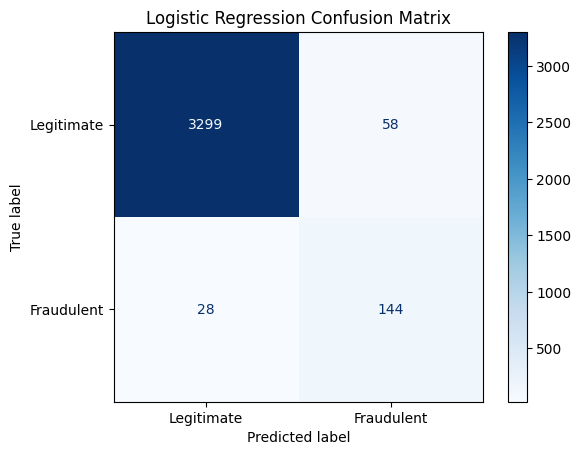

In [34]:
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(7,6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_pred,
    display_labels=["Legitimate", "Fraudulent"],
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

For Logistic Regression:

In [35]:
feature_names = tfidf.get_feature_names_out()

coefficients = lr_model.coef_[0]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

fraud_features = feature_importance.sort_values(
    by="Coefficient",
    ascending=False
).head(20)

legitimate_features = feature_importance.sort_values(
    by="Coefficient",
    ascending=True
).head(20)

print("Words strongly associated with fraudulent predictions:")
display(fraud_features)

print("\nWords strongly associated with legitimate predictions:")
display(legitimate_features)

Words strongly associated with fraudulent predictions:


,Feature,Coefficient
25678,link url,3.739997
47315,using link,3.548617
10882,data entry,3.534113
418,accion,3.295243
2421,apply using,3.253186
43223,subsea,3.060546
970,administrative,3.036588
28679,money,3.027552
2937,assistant,2.970055
14802,engineering,2.930213



Words strongly associated with legitimate predictions:


,Feature,Coefficient
44200,team,-2.661940
12722,digital,-2.541329
8174,companies,-2.533463
7205,clients,-2.325915
20072,growing,-2.287075
14896,english,-2.213560
27368,marketing,-2.206468
48401,web,-2.059777
3723,based,-2.043918
10077,creative,-1.932779


Model comparison chart

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,97.56,71.29,83.72,77.01
1,Naive Bayes,96.57,94.74,31.40,47.16
2,Linear SVM,98.64,90.79,80.23,85.19
3,Random Forest,97.31,73.33,70.35,71.81


<Figure size 1200x600 with 0 Axes>

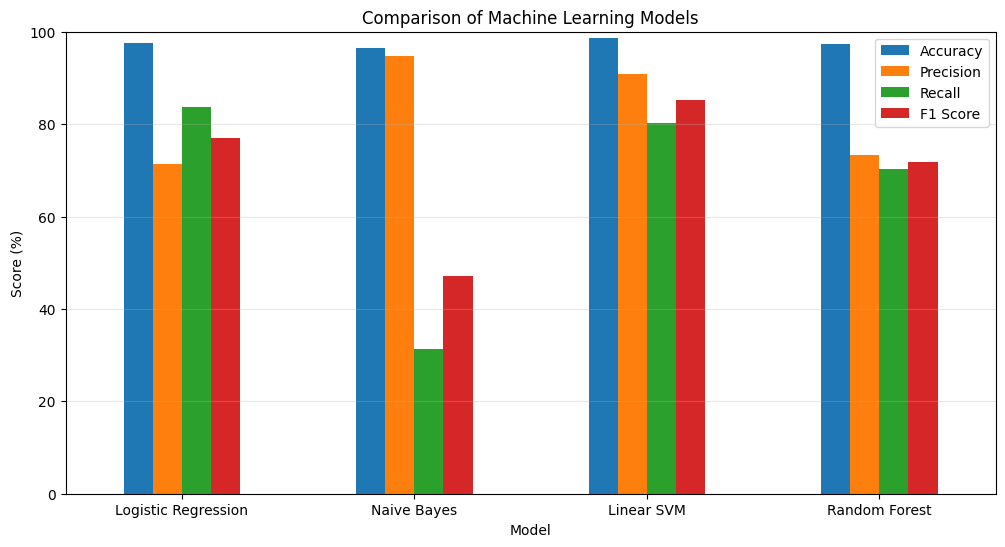

In [36]:
# Convert metrics to percentages for visualization

plot_results = results.copy()

for col in ["Accuracy", "Precision", "Recall", "F1 Score"]:
    plot_results[col] = plot_results[col] * 100

display(plot_results)

plt.figure(figsize=(12, 6))

plot_results.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].plot(kind="bar", figsize=(12, 6))

plt.title("Comparison of Machine Learning Models")
plt.ylabel("Score (%)")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

highest F1 model

In [37]:
best_f1_model = results.loc[
    results["F1 Score"].idxmax()
]

print("Model with highest F1 Score:")
print(best_f1_model)

Model with highest F1 Score:
Model        Linear SVM
Accuracy         0.9864
Precision        0.9079
Recall           0.8023
F1 Score         0.8519
Name: 2, dtype: object


In [38]:
best_recall_model = results.loc[
    results["Recall"].idxmax()
]

print("Model with highest Recall:")
print(best_recall_model)

Model with highest Recall:
Model        Logistic Regression
Accuracy                  0.9756
Precision                 0.7129
Recall                    0.8372
F1 Score                  0.7701
Name: 0, dtype: object


CONFUSION MATRICES FOR ALL MODELS

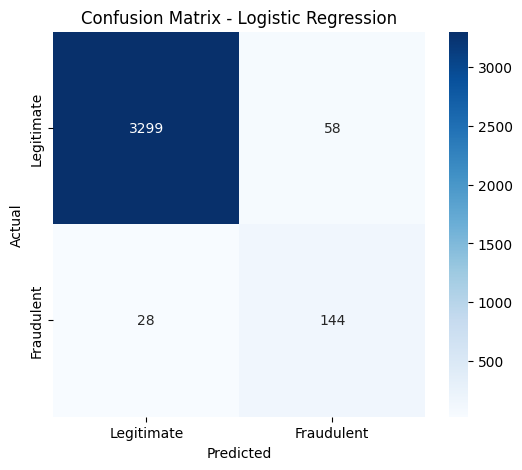

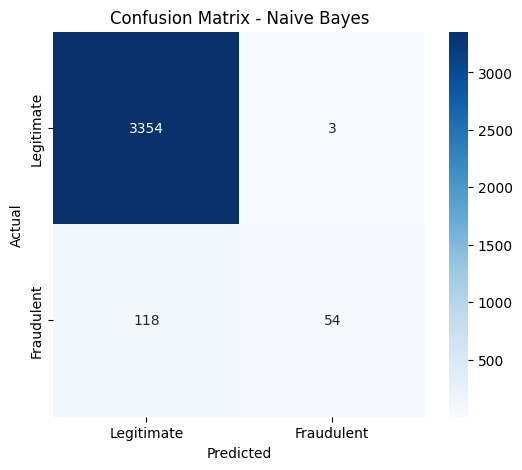

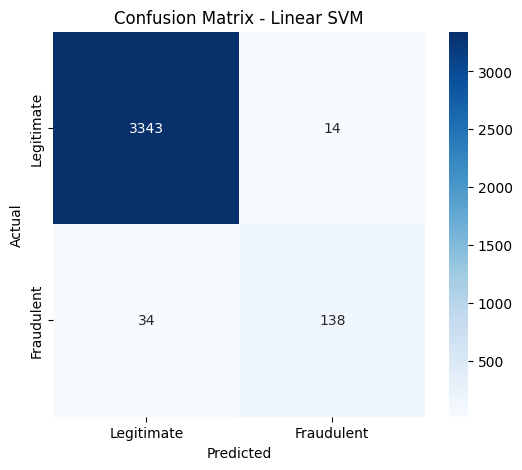

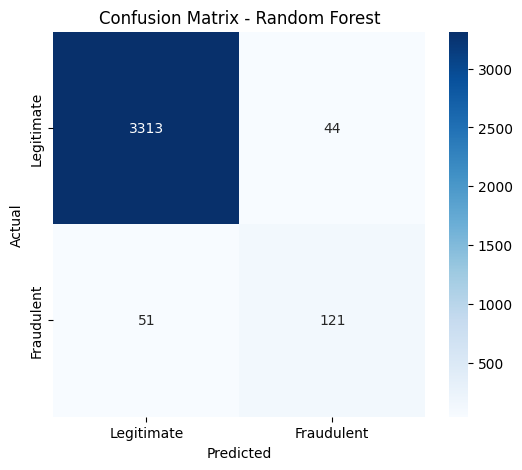

In [39]:
from sklearn.metrics import confusion_matrix

predictions = {
    "Logistic Regression": lr_pred,
    "Naive Bayes": nb_pred,
    "Linear SVM": svm_pred,
    "Random Forest": rf_pred
}

for model_name, predictions_model in predictions.items():

    cm = confusion_matrix(y_test, predictions_model)

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Legitimate", "Fraudulent"],
        yticklabels=["Legitimate", "Fraudulent"]
    )

    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

CROSS-VALIDATION

In [40]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Running 5-Fold Cross Validation...\n")

lr_cv = cross_val_score(
    lr_model,
    X_train_tfidf,
    y_train,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

nb_cv = cross_val_score(
    nb_model,
    X_train_tfidf,
    y_train,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

svm_cv = cross_val_score(
    svm_model,
    X_train_tfidf,
    y_train,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

print("Logistic Regression F1:", lr_cv)
print("Mean:", lr_cv.mean())

print("\nNaive Bayes F1:", nb_cv)
print("Mean:", nb_cv.mean())

print("\nLinear SVM F1:", svm_cv)
print("Mean:", svm_cv.mean())

Running 5-Fold Cross Validation...

Logistic Regression F1: [0.82312925 0.79858657 0.84285714 0.84722222 0.78892734]
Mean: 0.8201445049716692

Naive Bayes F1: [0.44198895 0.4        0.37426901 0.36686391 0.45652174]
Mean: 0.407928720116015

Linear SVM F1: [0.86153846 0.85271318 0.88973384 0.90118577 0.8359375 ]
Mean: 0.8682217501776412


TF-IDF experiment

In [41]:
tfidf_unigram = TfidfVectorizer(
    max_features=50000,
    stop_words="english",
    ngram_range=(1,1),
    min_df=2,
    max_df=0.95
)

X_train_uni = tfidf_unigram.fit_transform(X_train)
X_test_uni = tfidf_unigram.transform(X_test)

print("Unigram TF-IDF:")
print("Train shape:", X_train_uni.shape)
print("Test shape:", X_test_uni.shape)

Unigram TF-IDF:
Train shape: (14116, 24233)
Test shape: (3529, 24233)


Train Logistic Regression with unigram TF-IDF

In [42]:
lr_uni = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

lr_uni.fit(X_train_uni, y_train)

lr_uni_pred = lr_uni.predict(X_test_uni)

print("Unigram Logistic Regression")
print("=" * 50)

print("Accuracy :", accuracy_score(y_test, lr_uni_pred))
print("Precision:", precision_score(y_test, lr_uni_pred))
print("Recall   :", recall_score(y_test, lr_uni_pred))
print("F1 Score :", f1_score(y_test, lr_uni_pred))

Unigram Logistic Regression
Accuracy : 0.968546330405214
Precision: 0.6355555555555555
Recall   : 0.8313953488372093
F1 Score : 0.7204030226700252


In [43]:
print("Original TF-IDF F1 :", f1_score(y_test, lr_pred))
print("Unigram TF-IDF F1  :", f1_score(y_test, lr_uni_pred))

Original TF-IDF F1 : 0.7700534759358288
Unigram TF-IDF F1  : 0.7204030226700252


HYPERPARAMETER TUNING

In [44]:
from sklearn.model_selection import GridSearchCV

lr_param_grid = {
    "C": [0.1, 0.5, 1, 2, 5],
    "solver": ["liblinear", "lbfgs"]
}

lr_grid = GridSearchCV(
    LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    param_grid=lr_param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    verbose=1
)

lr_grid.fit(X_train_tfidf, y_train)

print("Best Parameters:")
print(lr_grid.best_params_)

print("\nBest Cross-Validation F1:")
print(lr_grid.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters:
{'C': 5, 'solver': 'lbfgs'}

Best Cross-Validation F1:
0.844796332626769


tuned Logistic Regression

In [45]:
tuned_lr = lr_grid.best_estimator_

tuned_lr_pred = tuned_lr.predict(X_test_tfidf)

print("Tuned Logistic Regression")
print("=" * 50)

print("Accuracy :", accuracy_score(y_test, tuned_lr_pred))
print("Precision:", precision_score(y_test, tuned_lr_pred))
print("Recall   :", recall_score(y_test, tuned_lr_pred))
print("F1 Score :", f1_score(y_test, tuned_lr_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    tuned_lr_pred,
    target_names=["Legitimate", "Fraudulent"]
))

Tuned Logistic Regression
Accuracy : 0.9821479172570133
Precision: 0.8114285714285714
Recall   : 0.8255813953488372
F1 Score : 0.8184438040345822

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.99      0.99      0.99      3357
  Fraudulent       0.81      0.83      0.82       172

    accuracy                           0.98      3529
   macro avg       0.90      0.91      0.90      3529
weighted avg       0.98      0.98      0.98      3529



Before vs After tuning

In [46]:
before_tuning = {
    "Accuracy": accuracy_score(y_test, lr_pred),
    "Precision": precision_score(y_test, lr_pred),
    "Recall": recall_score(y_test, lr_pred),
    "F1 Score": f1_score(y_test, lr_pred)
}

after_tuning = {
    "Accuracy": accuracy_score(y_test, tuned_lr_pred),
    "Precision": precision_score(y_test, tuned_lr_pred),
    "Recall": recall_score(y_test, tuned_lr_pred),
    "F1 Score": f1_score(y_test, tuned_lr_pred)
}

tuning_comparison = pd.DataFrame(
    [before_tuning, after_tuning],
    index=["Before Tuning", "After Tuning"]
)

display(tuning_comparison.round(4))

,Accuracy,Precision,Recall,F1 Score
Before Tuning,0.9756,0.7129,0.8372,0.7701
After Tuning,0.9821,0.8114,0.8256,0.8184


ROC-AUC

In [48]:
from sklearn.metrics import roc_auc_score, roc_curve

lr_probability = tuned_lr.predict_proba(X_test_tfidf)[:, 1]

roc_auc = roc_auc_score(
    y_test,
    lr_probability
)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9826083643341577


ROC Curve

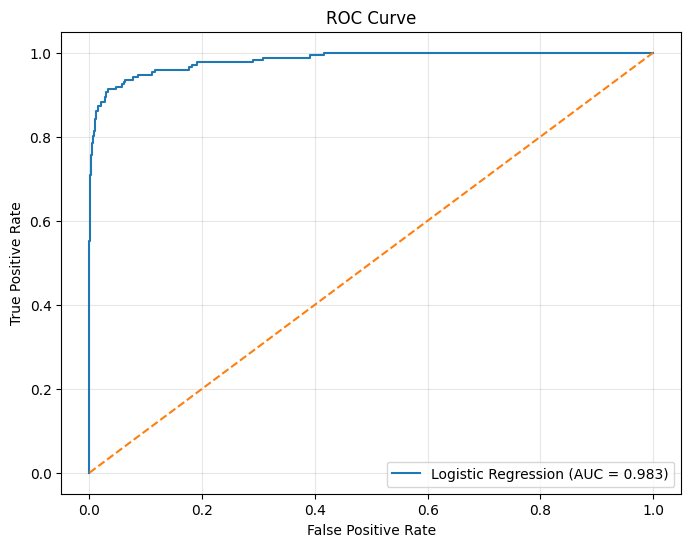

In [49]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    lr_probability
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

PRECISION-RECALL CURVE

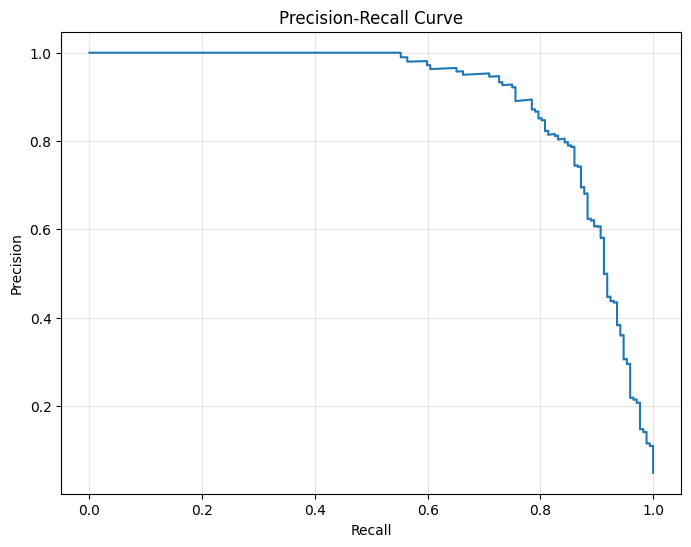

In [51]:
from sklearn.metrics import precision_recall_curve

precision_values, recall_values, pr_thresholds = precision_recall_curve(
    y_test,
    lr_probability
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_values,
    precision_values
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(alpha=0.3)

plt.show()

FINAL MODEL DECISION

In [52]:
final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Linear SVM",
        "Random Forest",
        "Tuned Logistic Regression"
    ],

    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, svm_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, tuned_lr_pred)
    ],

    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, nb_pred),
        precision_score(y_test, svm_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, tuned_lr_pred)
    ],

    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, nb_pred),
        recall_score(y_test, svm_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, tuned_lr_pred)
    ],

    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, nb_pred),
        f1_score(y_test, svm_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, tuned_lr_pred)
    ]
})

display(final_results.round(4))

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9756,0.7129,0.8372,0.7701
1,Naive Bayes,0.9657,0.9474,0.3140,0.4716
2,Linear SVM,0.9864,0.9079,0.8023,0.8519
3,Random Forest,0.9731,0.7333,0.7035,0.7181
4,Tuned Logistic Regression,0.9821,0.8114,0.8256,0.8184


FINAL CONFUSION MATRIX

<Figure size 700x600 with 0 Axes>

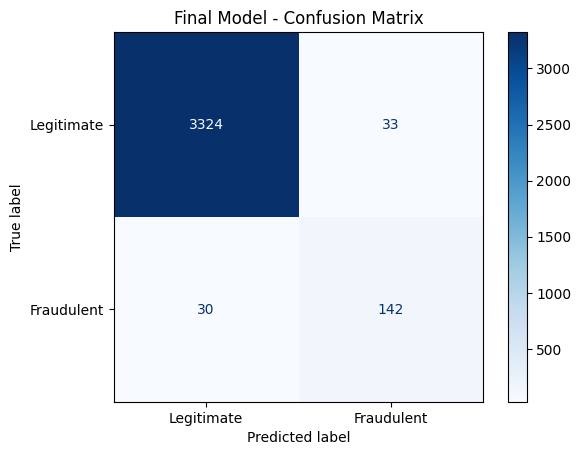

In [53]:
plt.figure(figsize=(7, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    tuned_lr_pred,
    display_labels=["Legitimate", "Fraudulent"],
    cmap="Blues"
)

plt.title("Final Model - Confusion Matrix")

plt.show()

FINAL MODEL EXPLANATION

In [54]:
final_coefficients = tuned_lr.coef_[0]

final_features = pd.DataFrame({
    "Feature": tfidf.get_feature_names_out(),
    "Coefficient": final_coefficients
})

print("Top features associated with fraudulent predictions:")

display(
    final_features
    .sort_values("Coefficient", ascending=False)
    .head(25)
)

Top features associated with fraudulent predictions:


,Feature,Coefficient
25678,link url,6.228968
47315,using link,6.084492
2421,apply using,5.581135
418,accion,5.568922
43223,subsea,5.198636
10882,data entry,4.775082
28679,money,4.685335
36725,receptionist,4.547931
25654,line requirements,4.530903
30403,offshore,4.525174


In [55]:
print("Top features associated with legitimate predictions:")

display(
    final_features
    .sort_values("Coefficient", ascending=True)
    .head(25)
)

Top features associated with legitimate predictions:


,Feature,Coefficient
8174,companies,-3.867564
12722,digital,-3.834361
44200,team,-3.632991
14896,english,-3.618129
20072,growing,-3.577679
7205,clients,-3.516751
3723,based,-3.204880
27368,marketing,-3.018475
39468,search,-2.935378
29566,new,-2.820693


FINAL MODEL

In [56]:
import joblib

joblib.dump(
    tfidf,
    "fake_job_tfidf_vectorizer.pkl"
)

joblib.dump(
    tuned_lr,
    "fake_job_detection_model.pkl"
)

print("Model and TF-IDF vectorizer saved successfully!")

Model and TF-IDF vectorizer saved successfully!


Prediction function

In [57]:
def predict_job_posting(job_text):

    # Clean input text
    cleaned_text = clean_text(job_text)

    # Convert text to TF-IDF
    text_vector = tfidf.transform([cleaned_text])

    # Prediction
    prediction = tuned_lr.predict(text_vector)[0]

    # Probability
    probability = tuned_lr.predict_proba(text_vector)[0]

    fraudulent_probability = probability[1] * 100
    legitimate_probability = probability[0] * 100

    if prediction == 1:
        result = "FRAUDULENT JOB POSTING"
    else:
        result = "LEGITIMATE JOB POSTING"

    print("Prediction:", result)
    print(f"Legitimate Probability: {legitimate_probability:.2f}%")
    print(f"Fraudulent Probability: {fraudulent_probability:.2f}%")

    return result

Test with a sample posting

In [58]:
sample_job = """
We are looking for a Software Developer to join our technology team.

The candidate should have experience in Python, JavaScript,
web development and database systems.

The selected candidate will work with our development team
to design, implement and maintain software applications.

Candidates should have good communication and problem solving skills.
"""

predict_job_posting(sample_job)

Prediction: LEGITIMATE JOB POSTING
Legitimate Probability: 96.71%
Fraudulent Probability: 3.29%


'LEGITIMATE JOB POSTING'

THE PROFESSIONAL UI

In [59]:
!pip install -q gradio

In [60]:
import gradio as gr

def predict_from_interface(
    title,
    company_profile,
    description,
    requirements,
    benefits
):

    combined = f"""
    {title}
    {company_profile}
    {description}
    {requirements}
    {benefits}
    """

    cleaned = clean_text(combined)

    vector = tfidf.transform([cleaned])

    prediction = tuned_lr.predict(vector)[0]

    probabilities = tuned_lr.predict_proba(vector)[0]

    legitimate_probability = probabilities[0] * 100
    fraudulent_probability = probabilities[1] * 100

    if prediction == 1:

        result = "⚠️ FRAUDULENT JOB POSTING"

    else:

        result = "✅ LEGITIMATE JOB POSTING"

    return (
        result,
        f"Legitimate: {legitimate_probability:.2f}%",
        f"Fraudulent: {fraudulent_probability:.2f}%"
    )

In [61]:
demo = gr.Interface(

    fn=predict_from_interface,

    inputs=[
        gr.Textbox(
            label="Job Title",
            placeholder="Enter job title..."
        ),

        gr.Textbox(
            label="Company Profile",
            placeholder="Enter company information..."
        ),

        gr.Textbox(
            label="Job Description",
            placeholder="Enter complete job description...",
            lines=6
        ),

        gr.Textbox(
            label="Requirements",
            placeholder="Enter job requirements...",
            lines=5
        ),

        gr.Textbox(
            label="Benefits",
            placeholder="Enter benefits...",
            lines=4
        )
    ],

    outputs=[
        gr.Textbox(label="Prediction"),
        gr.Textbox(label="Legitimate Probability"),
        gr.Textbox(label="Fraudulent Probability")
    ],

    title="🔍 Fake Job Posting Detection System",

    description="""
    Machine Learning Based Fake Job Posting Detection System.

    Enter the details of a job posting to estimate whether
    the posting is legitimate or potentially fraudulent.
    """
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8d3744ab33c75b3014.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


final results cell

In [62]:
final_metrics = {
    "Accuracy": accuracy_score(y_test, tuned_lr_pred),
    "Precision": precision_score(y_test, tuned_lr_pred),
    "Recall": recall_score(y_test, tuned_lr_pred),
    "F1 Score": f1_score(y_test, tuned_lr_pred),
    "ROC-AUC": roc_auc
}

final_metrics_df = pd.DataFrame(
    [final_metrics]
).round(4)

display(final_metrics_df)

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,0.9821,0.8114,0.8256,0.8184,0.9826


Final model report

In [63]:
print("FINAL MODEL REPORT")
print("=" * 60)

print("\nModel: Tuned Logistic Regression")
print("Features: TF-IDF text features")
print("N-grams: Unigrams + Bigrams")
print("Class balancing: Balanced")
print("Dataset size after duplicate removal:", len(df))

print("\nPerformance:")
print(f"Accuracy : {accuracy_score(y_test, tuned_lr_pred)*100:.2f}%")
print(f"Precision: {precision_score(y_test, tuned_lr_pred)*100:.2f}%")
print(f"Recall   : {recall_score(y_test, tuned_lr_pred)*100:.2f}%")
print(f"F1 Score : {f1_score(y_test, tuned_lr_pred)*100:.2f}%")
print(f"ROC-AUC  : {roc_auc:.4f}")

FINAL MODEL REPORT

Model: Tuned Logistic Regression
Features: TF-IDF text features
N-grams: Unigrams + Bigrams
Class balancing: Balanced
Dataset size after duplicate removal: 17645

Performance:
Accuracy : 98.21%
Precision: 81.14%
Recall   : 82.56%
F1 Score : 81.84%
ROC-AUC  : 0.9826


Install/update Gradio

In [64]:
!pip install -q --upgrade gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 kB 4.2 MB/s eta 0:00:00


Professional prediction function

In [65]:
def professional_prediction(
    title,
    company_profile,
    description,
    requirements,
    benefits
):

    # Combine all text fields
    combined_text = f"""
    {title}
    {company_profile}
    {description}
    {requirements}
    {benefits}
    """

    # Clean text
    cleaned_text = clean_text(combined_text)

    # TF-IDF transformation
    text_vector = tfidf.transform([cleaned_text])

    # Prediction
    prediction = tuned_lr.predict(text_vector)[0]
    probabilities = tuned_lr.predict_proba(text_vector)[0]

    legitimate_probability = probabilities[0] * 100
    fraudulent_probability = probabilities[1] * 100

    if prediction == 1:
        result = "⚠️ POTENTIALLY FRAUDULENT"
        explanation = (
            "The model detected textual patterns that are more "
            "associated with fraudulent job postings in the training data."
        )
    else:
        result = "✅ LIKELY LEGITIMATE"
        explanation = (
            "The model detected textual patterns that are more "
            "associated with legitimate job postings in the training data."
        )

    return (
        result,
        f"{legitimate_probability:.2f}%",
        f"{fraudulent_probability:.2f}%",
        explanation
    )

Professional UI

In [66]:
import gradio as gr

custom_css = """
body {
    background: #f5f7fb;
}

.gradio-container {
    max-width: 1200px !important;
    margin: auto !important;
}

.title {
    text-align: center;
    margin-bottom: 10px;
}

.subtitle {
    text-align: center;
    color: #666;
    margin-bottom: 25px;
}

.result-box {
    padding: 20px;
    border-radius: 12px;
}
"""

with gr.Blocks(
    theme=gr.themes.Soft(),
    css=custom_css,
    title="Fake Job Posting Detector"
) as demo:

    gr.Markdown(
        """
        # 🔍 Fake Job Posting Detector
        """,
        elem_classes="title"
    )

    gr.Markdown(
        """
        ### Machine Learning Based Fraud Detection System

        Analyze a job posting using Natural Language Processing and
        Machine Learning to estimate whether it is potentially fraudulent
        or likely legitimate.
        """,
        elem_classes="subtitle"
    )

    with gr.Row():

        # =========================
        # LEFT SIDE — INPUT
        # =========================

        with gr.Column(scale=1):

            gr.Markdown("## 📝 Job Posting Details")

            title_input = gr.Textbox(
                label="Job Title",
                placeholder="Example: Software Developer"
            )

            company_input = gr.Textbox(
                label="Company Profile",
                placeholder="Enter company information...",
                lines=4
            )

            description_input = gr.Textbox(
                label="Job Description",
                placeholder="Enter the complete job description...",
                lines=7
            )

            requirements_input = gr.Textbox(
                label="Requirements",
                placeholder="Enter required skills, education, experience...",
                lines=5
            )

            benefits_input = gr.Textbox(
                label="Benefits",
                placeholder="Enter salary, benefits and other information...",
                lines=4
            )

            analyze_button = gr.Button(
                "🔎 ANALYZE JOB POSTING",
                variant="primary",
                size="lg"
            )

        # =========================
        # RIGHT SIDE — RESULT
        # =========================

        with gr.Column(scale=1):

            gr.Markdown("## 📊 Detection Result")

            prediction_output = gr.Textbox(
                label="Prediction",
                interactive=False
            )

            legitimate_output = gr.Textbox(
                label="Legitimate Probability",
                interactive=False
            )

            fraudulent_output = gr.Textbox(
                label="Fraudulent Probability",
                interactive=False
            )

            explanation_output = gr.Textbox(
                label="Model Interpretation",
                lines=5,
                interactive=False
            )

            gr.Markdown(
                """
                ### ⚠️ Important

                This system provides a **machine-learning-based estimate**.
                A prediction should not be treated as definitive proof that
                a job posting is fraudulent.
                """
            )

    analyze_button.click(
        fn=professional_prediction,
        inputs=[
            title_input,
            company_input,
            description_input,
            requirements_input,
            benefits_input
        ],
        outputs=[
            prediction_output,
            legitimate_output,
            fraudulent_output,
            explanation_output
        ]
    )

    gr.Markdown(
        """
        ---

        **Technology:** Python • NLP • TF-IDF • Logistic Regression • Gradio

        **Project:** Fake Job Posting Detection
        """
    )

demo.launch(share=True)

/tmp/ipykernel_1688/1290943381.py:30: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://557c03d9fb0bee5825.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


final technical check

In [67]:
print("FINAL PROJECT CHECK")
print("=" * 50)

print("Dataset rows:", len(df))
print("Dataset columns:", len(df.columns))

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nFinal Model:")
print("Tuned Logistic Regression")

print("\nFinal Metrics:")
print(f"Accuracy : {accuracy_score(y_test, tuned_lr_pred)*100:.2f}%")
print(f"Precision: {precision_score(y_test, tuned_lr_pred)*100:.2f}%")
print(f"Recall   : {recall_score(y_test, tuned_lr_pred)*100:.2f}%")
print(f"F1 Score : {f1_score(y_test, tuned_lr_pred)*100:.2f}%")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nSaved Files:")
print("✓ fake_job_detection_model.pkl")
print("✓ fake_job_tfidf_vectorizer.pkl")
print("✓ Fake_Job_Posting_Detection.ipynb")

FINAL PROJECT CHECK
Dataset rows: 17645
Dataset columns: 26
Training samples: 14116
Testing samples: 3529

Final Model:
Tuned Logistic Regression

Final Metrics:
Accuracy : 98.21%
Precision: 81.14%
Recall   : 82.56%
F1 Score : 81.84%
ROC-AUC  : 0.9826

Saved Files:
✓ fake_job_detection_model.pkl
✓ fake_job_tfidf_vectorizer.pkl
✓ Fake_Job_Posting_Detection.ipynb
